<ipython-input-8-68c3abfd304a>:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


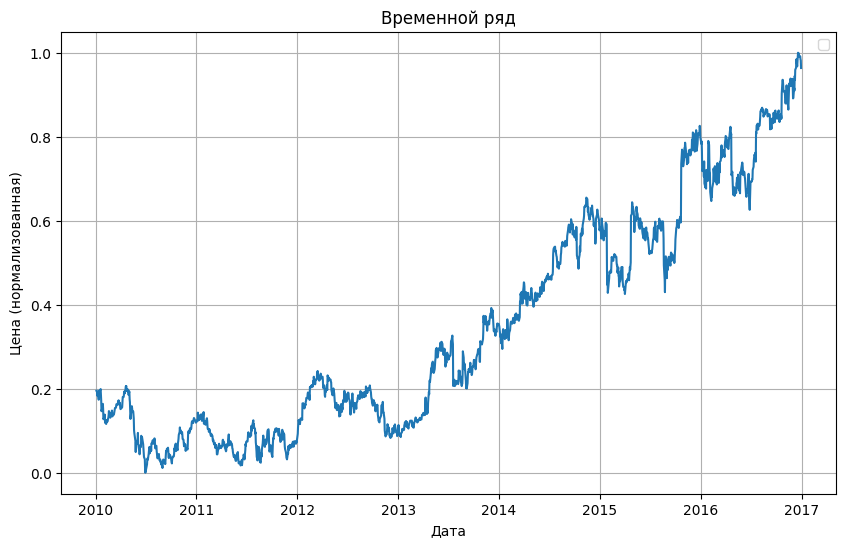

Epoch 1/50, Loss: 0.0596
Epoch 2/50, Loss: 0.0029
Epoch 3/50, Loss: 0.0011
Epoch 4/50, Loss: 0.0010
Epoch 5/50, Loss: 0.0009
Epoch 6/50, Loss: 0.0009
Epoch 7/50, Loss: 0.0010
Epoch 8/50, Loss: 0.0008
Epoch 9/50, Loss: 0.0008
Epoch 10/50, Loss: 0.0008
Epoch 11/50, Loss: 0.0009
Epoch 12/50, Loss: 0.0008
Epoch 13/50, Loss: 0.0008
Epoch 14/50, Loss: 0.0008
Epoch 15/50, Loss: 0.0007
Epoch 16/50, Loss: 0.0008
Epoch 17/50, Loss: 0.0007
Epoch 18/50, Loss: 0.0007
Epoch 19/50, Loss: 0.0007
Epoch 20/50, Loss: 0.0006
Epoch 21/50, Loss: 0.0007
Epoch 22/50, Loss: 0.0006
Epoch 23/50, Loss: 0.0007
Epoch 24/50, Loss: 0.0007
Epoch 25/50, Loss: 0.0006
Epoch 26/50, Loss: 0.0006
Epoch 27/50, Loss: 0.0006
Epoch 28/50, Loss: 0.0006
Epoch 29/50, Loss: 0.0005
Epoch 30/50, Loss: 0.0006
Epoch 31/50, Loss: 0.0007
Epoch 32/50, Loss: 0.0006
Epoch 33/50, Loss: 0.0005
Epoch 34/50, Loss: 0.0005
Epoch 35/50, Loss: 0.0005
Epoch 36/50, Loss: 0.0006
Epoch 37/50, Loss: 0.0005
Epoch 38/50, Loss: 0.0005
Epoch 39/50, Loss: 0.

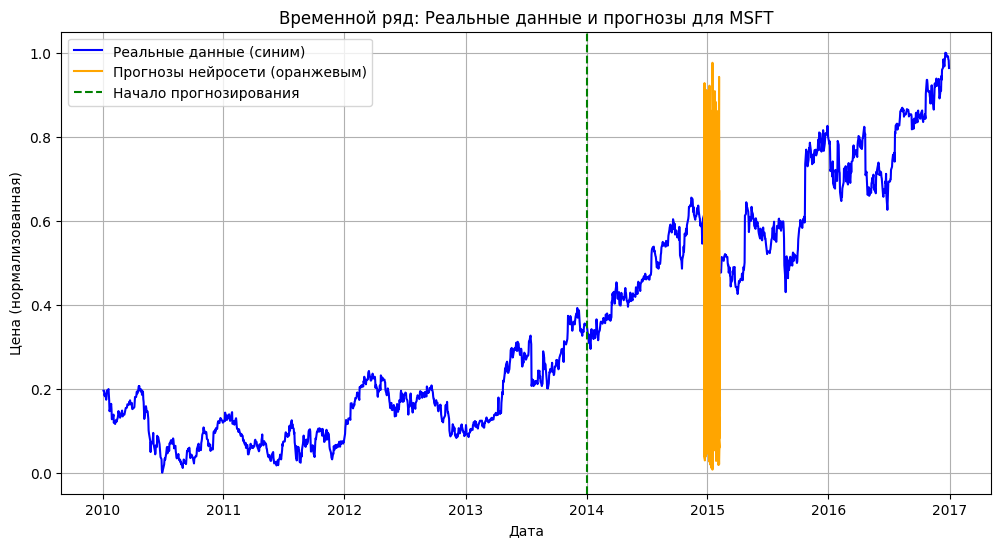

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Загрузка данных
root_dir = "/content/drive/MyDrive/stonks_dataset/AMZN_data.csv"
# Загрузка данных
data = pd.read_csv(root_dir)
data['date'] = pd.to_datetime(data['date'])
data = data.sort_values(by=['symbol', 'date'])

# Нормализация цен для каждой Asset
scalers = {}
data_scaled = []
for asset in data['symbol'].unique():
    asset_data = data[data['symbol'] == asset]
    scaler = MinMaxScaler()
    asset_data['close'] = scaler.fit_transform(asset_data[['close']])
    scalers[asset] = scaler
    data_scaled.append(asset_data)
data = pd.concat(data_scaled)

# Проверка данных перед визуализацией
#asset_data = data[data['symbol'] == asset_to_plot]
#if asset_data.empty:
#    print(f"Данные для актива {asset_to_plot} отсутствуют!")
#else:
plt.figure(figsize=(10, 6))
plt.plot(asset_data['date'], asset_data['close']) #, label=f'Временной ряд для {asset_to_plot}')
plt.xlabel('Дата')
plt.ylabel('Цена (нормализованная)')
plt.title(f'Временной ряд')
plt.legend()
plt.grid()
plt.show()






# Создание набора данных для временных рядов
class TimeSeriesDataset(Dataset):
    def __init__(self, data, asset, seq_length):
        self.data = data[data['symbol'] == asset]
        self.seq_length = seq_length

        self.prices = self.data['close'].values

    def __len__(self):
        return len(self.prices) - self.seq_length

    def __getitem__(self, idx):
        x = self.prices[idx:idx + self.seq_length]
        y = self.prices[idx + self.seq_length]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

# Параметры
SEQ_LENGTH = 12  # длина временного окна
BATCH_SIZE = 32
LEARNING_RATE = 0.001
EPOCHS = 50

# Подготовка данных для конкретного актива
asset = 'MSFT'  # замените на нужный актив
dataset = TimeSeriesDataset(data, asset, SEQ_LENGTH)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Определение модели
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

# Инициализация модели
model = LSTMModel(input_size=1, hidden_size=64, num_layers=2, output_size=1).to(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Обучение модели
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for x, y in train_loader:
        x = x.unsqueeze(-1).to(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
        y = y.to(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))

        outputs = model(x)
        loss = criterion(outputs.squeeze(), y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print(f'Epoch {epoch+1}/{EPOCHS}, Loss: {train_loss/len(train_loader):.4f}')

# Прогнозирование на тестовых данных
model.eval()
predictions = []
real_values = []
dates = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.unsqueeze(-1).to(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
        y = y.to(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))

        # Прогнозируем
        outputs = model(x)
        predictions.append(outputs.squeeze().cpu().numpy())
        real_values.append(y.cpu().numpy())

        # Сохраняем даты для текущей последовательности
        batch_start_idx = test_dataset.indices[0] + SEQ_LENGTH
        batch_dates = test_dataset.dataset.data['date'].iloc[batch_start_idx:batch_start_idx + len(y)].values
        dates.extend(batch_dates)  # Используем extend вместо append

# Преобразуем списки в массивы
predictions = np.concatenate(predictions)
real_values = np.concatenate(real_values)
dates = np.array(dates)  # Преобразуем список дат в массив

# Визуализация: отображаем реальные данные синим и предсказания оранжевым
plt.figure(figsize=(12, 6))
plt.plot(data[data['symbol'] == asset]['date'], data[data['symbol'] == asset]['close'], label='Реальные данные (синим)', color='blue')
plt.plot(dates, predictions, label='Прогнозы нейросети (оранжевым)', color='orange')

# Добавление аннотаций
plt.axvline(pd.to_datetime("2014-01-01"), color='green', linestyle='--', label='Начало прогнозирования')

plt.xlabel('Дата')
plt.ylabel('Цена (нормализованная)')
plt.title(f'Временной ряд: Реальные данные и прогнозы для {asset}')
plt.legend()
plt.grid(True)
plt.show()




In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Загрузка данных


root_dir = "/content/drive/MyDrive/dataset_4/financial_portfolio_data.csv"
# Загрузка данных
data = pd.read_csv(root_dir)
#data = pd.read_csv('your_dataset.csv')
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values(by=['Asset', 'Date'])

# Нормализация цен для каждой Asset
scalers = {}
data_scaled = []
for asset in data['Asset'].unique():
    asset_data = data[data['Asset'] == asset]
    scaler = MinMaxScaler()
    asset_data['Price'] = scaler.fit_transform(asset_data[['Price']])
    scalers[asset] = scaler
    data_scaled.append(asset_data)
data = pd.concat(data_scaled)

# Создание набора данных для временных рядов
class TimeSeriesDataset(Dataset):
    def __init__(self, data, asset, seq_length):
        self.data = data[data['Asset'] == asset]
        self.seq_length = seq_length

        self.prices = self.data['Price'].values

    def __len__(self):
        return len(self.prices) - self.seq_length

    def __getitem__(self, idx):
        x = self.prices[idx:idx + self.seq_length]
        y = self.prices[idx + self.seq_length]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

# Параметры
SEQ_LENGTH = 12  # длина временного окна
BATCH_SIZE = 32
LEARNING_RATE = 0.001
EPOCHS = 50

# Подготовка данных для конкретного актива
asset = 'Bond B'  # замените на нужный актив
dataset = TimeSeriesDataset(data, asset, SEQ_LENGTH)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Определение модели
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

# Инициализация модели
model = LSTMModel(input_size=1, hidden_size=64, num_layers=2, output_size=1).to(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Обучение модели
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for x, y in train_loader:
        x = x.unsqueeze(-1).to(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
        y = y.to(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))

        outputs = model(x)
        loss = criterion(outputs.squeeze(), y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print(f'Epoch {epoch+1}/{EPOCHS}, Loss: {train_loss/len(train_loader):.4f}')

# Оценка модели
model.eval()
test_loss = 0
with torch.no_grad():
    for x, y in test_loader:
        x = x.unsqueeze(-1).to(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
        y = y.to(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))

        outputs = model(x)
        loss = criterion(outputs.squeeze(), y)
        test_loss += loss.item()

print(f'Test Loss: {test_loss/len(test_loader):.4f}')

# Пример прогноза
sample, _ = dataset[0]
sample = sample.unsqueeze(0).unsqueeze(-1).to(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
model.eval()
with torch.no_grad():
    prediction = model(sample).item()
    print(f'Прогноз: {prediction}')


<ipython-input-46-9369f557ce0f>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  asset_data['Price'] = scaler.fit_transform(asset_data[['Price']])
<ipython-input-46-9369f557ce0f>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  asset_data['Price'] = scaler.fit_transform(asset_data[['Price']])
<ipython-input-46-9369f557ce0f>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the document

Epoch 1/50, Loss: 0.4995
Epoch 2/50, Loss: 0.4000
Epoch 3/50, Loss: 0.3303
Epoch 4/50, Loss: 0.2389
Epoch 5/50, Loss: 0.1502
Epoch 6/50, Loss: 0.1036
Epoch 7/50, Loss: 0.1414
Epoch 8/50, Loss: 0.1030
Epoch 9/50, Loss: 0.0858
Epoch 10/50, Loss: 0.1020
Epoch 11/50, Loss: 0.0938
Epoch 12/50, Loss: 0.0933
Epoch 13/50, Loss: 0.0895
Epoch 14/50, Loss: 0.0892
Epoch 15/50, Loss: 0.0913
Epoch 16/50, Loss: 0.0937
Epoch 17/50, Loss: 0.0828
Epoch 18/50, Loss: 0.0910
Epoch 19/50, Loss: 0.0822
Epoch 20/50, Loss: 0.0929
Epoch 21/50, Loss: 0.0997
Epoch 22/50, Loss: 0.0932
Epoch 23/50, Loss: 0.0923
Epoch 24/50, Loss: 0.0901
Epoch 25/50, Loss: 0.0901
Epoch 26/50, Loss: 0.0859
Epoch 27/50, Loss: 0.0957
Epoch 28/50, Loss: 0.0855
Epoch 29/50, Loss: 0.0836
Epoch 30/50, Loss: 0.0861
Epoch 31/50, Loss: 0.0978
Epoch 32/50, Loss: 0.0878
Epoch 33/50, Loss: 0.0910
Epoch 34/50, Loss: 0.0880
Epoch 35/50, Loss: 0.0888
Epoch 36/50, Loss: 0.0922
Epoch 37/50, Loss: 0.0904
Epoch 38/50, Loss: 0.0920
Epoch 39/50, Loss: 0.

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Загрузка данных
data = pd.read_csv('your_dataset.csv')
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values(by=['Asset', 'Date'])

# Нормализация цен для каждой Asset
scalers = {}
data_scaled = []
for asset in data['Asset'].unique():
    asset_data = data[data['Asset'] == asset]
    scaler = MinMaxScaler()
    asset_data['Price'] = scaler.fit_transform(asset_data[['Price']])
    scalers[asset] = scaler
    data_scaled.append(asset_data)
data = pd.concat(data_scaled)

# Визуализация временного ряда
asset_to_plot = 'Asset_1'  # замените на нужный актив
asset_data = data[data['Asset'] == asset_to_plot]
plt.figure(figsize=(10, 6))
plt.plot(asset_data['Date'], asset_data['Price'], label=f'Временной ряд для {asset_to_plot}')
plt.xlabel('Дата')
plt.ylabel('Цена (нормализованная)')
plt.title(f'Временной ряд для {asset_to_plot}')
plt.legend()
plt.grid()
plt.show()

# Создание набора данных для временных рядов
class TimeSeriesDataset(Dataset):
    def __init__(self, data, asset, seq_length):
        self.data = data[data['Asset'] == asset]
        self.seq_length = seq_length

        self.prices = self.data['Price'].values

    def __len__(self):
        return len(self.prices) - self.seq_length

    def __getitem__(self, idx):
        x = self.prices[idx:idx + self.seq_length]
        y = self.prices[idx + self.seq_length]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

# Параметры
SEQ_LENGTH = 12  # длина временного окна
BATCH_SIZE = 32
LEARNING_RATE = 0.001
EPOCHS = 50

# Подготовка данных для конкретного актива
asset = 'Ищ'  # замените на нужный актив
dataset = TimeSeriesDataset(data, asset, SEQ_LENGTH)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Определение модели
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

# Инициализация модели
model = LSTMModel(input_size=1, hidden_size=64, num_layers=2, output_size=1).to(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Обучение модели
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for x, y in train_loader:
        x = x.unsqueeze(-1).to(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
        y = y.to(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))

        outputs = model(x)
        loss = criterion(outputs.squeeze(), y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print(f'Epoch {epoch+1}/{EPOCHS}, Loss: {train_loss/len(train_loader):.4f}')

# Оценка модели
model.eval()
test_loss = 0
with torch.no_grad():
    for x, y in test_loader:
        x = x.unsqueeze(-1).to(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
        y = y.to(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))

        outputs = model(x)
        loss = criterion(outputs.squeeze(), y)
        test_loss += loss.item()

print(f'Test Loss: {test_loss/len(test_loader):.4f}')

# Пример прогноза
sample, _ = dataset[0]
sample = sample.unsqueeze(0).unsqueeze(-1).to(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
model.eval()
with torch.no_grad():
    prediction = model(sample).item()
    print(f'Прогноз: {prediction}')


In [ ]:
import pandas as pd
#input_file = "/content/drive/MyDrive/dataset_4/prices.csv"
#output_file = "/content/drive/MyDrive/stonks_dataset/AAPL_data.csv"
def filter_aapl_data(input_file, output_file):
    """
    Фильтрует данные из CSV-файла, оставляя только строки с symbol 'AAPL',
    и сохраняет их в новый CSV-файл.

    Args:
        input_file (str): Путь к входному CSV-файлу (prices.csv).
        output_file (str): Путь к выходному CSV-файлу (AAPL_data.csv).
    """
    try:
        # Читаем CSV-файл в DataFrame
        df = pd.read_csv(input_file)

        # Фильтруем DataFrame, оставляя только строки, где symbol равен 'AAPL'
        aapl_df = df[df['symbol'] == 'AAPL']

        # Сохраняем отфильтрованный DataFrame в новый CSV-файл
        aapl_df.to_csv(output_file, index=False)

        print(f"Данные для AAPL успешно отфильтрованы и сохранены в {output_file}")

    except FileNotFoundError:
        print(f"Ошибка: Файл {input_file} не найден.")
    except KeyError:
        print(f"Ошибка: Столбец 'symbol' не найден в файле {input_file}.")
    except Exception as e:
        print(f"Произошла ошибка: {e}")


if __name__ == "__main__":
    input_csv_file = "/content/drive/MyDrive/stonks_dataset/prices.csv"  # Замените, если у вас другое имя файла
    output_csv_file = "/content/drive/MyDrive/stonks_dataset/AAPL_data.csv"
    filter_aapl_data(input_csv_file, output_csv_file)

Данные для AAPL успешно отфильтрованы и сохранены в /content/drive/MyDrive/stonks_dataset/AAPL_data.csv


In [ ]:
import pandas as pd
#input_file = "/content/drive/MyDrive/dataset_4/prices.csv"
#output_file = "/content/drive/MyDrive/stonks_dataset/AAPL_data.csv"
def filter_aapl_data(input_file, output_file):
    """
    Фильтрует данные из CSV-файла, оставляя только строки с symbol 'AAPL',
    и сохраняет их в новый CSV-файл.

    Args:
        input_file (str): Путь к входному CSV-файлу (prices.csv).
        output_file (str): Путь к выходному CSV-файлу (AAPL_data.csv).
    """
    try:
        # Читаем CSV-файл в DataFrame
        df = pd.read_csv(input_file)

        # Фильтруем DataFrame, оставляя только строки, где symbol равен 'AAPL'
        aapl_df = df[df['symbol'] == 'GOOGL']

        # Сохраняем отфильтрованный DataFrame в новый CSV-файл
        aapl_df.to_csv(output_file, index=False)

        print(f"Данные для AAPL успешно отфильтрованы и сохранены в {output_file}")

    except FileNotFoundError:
        print(f"Ошибка: Файл {input_file} не найден.")
    except KeyError:
        print(f"Ошибка: Столбец 'symbol' не найден в файле {input_file}.")
    except Exception as e:
        print(f"Произошла ошибка: {e}")


if __name__ == "__main__":
    input_csv_file = "/content/drive/MyDrive/stonks_dataset/prices.csv"  # Замените, если у вас другое имя файла
    output_csv_file = "/content/drive/MyDrive/stonks_dataset/GOOGL_data.csv"
    filter_aapl_data(input_csv_file, output_csv_file)

Данные для AAPL успешно отфильтрованы и сохранены в /content/drive/MyDrive/stonks_dataset/GOOGL_data.csv


In [ ]:
import pandas as pd
#input_file = "/content/drive/MyDrive/dataset_4/prices.csv"
#output_file = "/content/drive/MyDrive/stonks_dataset/AAPL_data.csv"
def filter_aapl_data(input_file, output_file):
    """
    Фильтрует данные из CSV-файла, оставляя только строки с symbol 'AAPL',
    и сохраняет их в новый CSV-файл.

    Args:
        input_file (str): Путь к входному CSV-файлу (prices.csv).
        output_file (str): Путь к выходному CSV-файлу (AAPL_data.csv).
    """
    try:
        # Читаем CSV-файл в DataFrame
        df = pd.read_csv(input_file)

        # Фильтруем DataFrame, оставляя только строки, где symbol равен 'AAPL'
        aapl_df = df[df['symbol'] == 'MSFT']

        # Сохраняем отфильтрованный DataFrame в новый CSV-файл
        aapl_df.to_csv(output_file, index=False)

        print(f"Данные для AAPL успешно отфильтрованы и сохранены в {output_file}")

    except FileNotFoundError:
        print(f"Ошибка: Файл {input_file} не найден.")
    except KeyError:
        print(f"Ошибка: Столбец 'symbol' не найден в файле {input_file}.")
    except Exception as e:
        print(f"Произошла ошибка: {e}")


if __name__ == "__main__":
    input_csv_file = "/content/drive/MyDrive/stonks_dataset/prices.csv"  # Замените, если у вас другое имя файла
    output_csv_file = "/content/drive/MyDrive/stonks_dataset/MSFT_data.csv"
    filter_aapl_data(input_csv_file, output_csv_file)

Данные для AAPL успешно отфильтрованы и сохранены в /content/drive/MyDrive/stonks_dataset/MSFT_data.csv


In [ ]:
import pandas as pd
#input_file = "/content/drive/MyDrive/dataset_4/prices.csv"
#output_file = "/content/drive/MyDrive/stonks_dataset/AAPL_data.csv"
def filter_aapl_data(input_file, output_file):
    """
    Фильтрует данные из CSV-файла, оставляя только строки с symbol 'AAPL',
    и сохраняет их в новый CSV-файл.

    Args:
        input_file (str): Путь к входному CSV-файлу (prices.csv).
        output_file (str): Путь к выходному CSV-файлу (AAPL_data.csv).
    """
    try:
        # Читаем CSV-файл в DataFrame
        df = pd.read_csv(input_file)

        # Фильтруем DataFrame, оставляя только строки, где symbol равен 'AAPL'
        aapl_df = df[df['symbol'] == 'MSFT']

        # Сохраняем отфильтрованный DataFrame в новый CSV-файл
        aapl_df.to_csv(output_file, index=False)

        print(f"Данные для AAPL успешно отфильтрованы и сохранены в {output_file}")

    except FileNotFoundError:
        print(f"Ошибка: Файл {input_file} не найден.")
    except KeyError:
        print(f"Ошибка: Столбец 'symbol' не найден в файле {input_file}.")
    except Exception as e:
        print(f"Произошла ошибка: {e}")


if __name__ == "__main__":
    input_csv_file = "/content/drive/MyDrive/stonks_dataset/prices.csv"  # Замените, если у вас другое имя файла
    output_csv_file = "/content/drive/MyDrive/stonks_dataset/AMZN_data.csv"
    filter_aapl_data(input_csv_file, output_csv_file)

Данные для AAPL успешно отфильтрованы и сохранены в /content/drive/MyDrive/stonks_dataset/AMZN_data.csv


In [ ]:
import pandas as pd
#input_file = "/content/drive/MyDrive/dataset_4/prices.csv"
#output_file = "/content/drive/MyDrive/stonks_dataset/AAPL_data.csv"
def filter_aapl_data(input_file, output_file):
    """
    Фильтрует данные из CSV-файла, оставляя только строки с symbol 'AAPL',
    и сохраняет их в новый CSV-файл.

    Args:
        input_file (str): Путь к входному CSV-файлу (prices.csv).
        output_file (str): Путь к выходному CSV-файлу (AAPL_data.csv).
    """
    try:
        # Читаем CSV-файл в DataFrame
        df = pd.read_csv(input_file)

        # Фильтруем DataFrame, оставляя только строки, где symbol равен 'AAPL'
        aapl_df = df[df['symbol'] == 'FB']

        # Сохраняем отфильтрованный DataFrame в новый CSV-файл
        aapl_df.to_csv(output_file, index=False)

        print(f"Данные для AAPL успешно отфильтрованы и сохранены в {output_file}")

    except FileNotFoundError:
        print(f"Ошибка: Файл {input_file} не найден.")
    except KeyError:
        print(f"Ошибка: Столбец 'symbol' не найден в файле {input_file}.")
    except Exception as e:
        print(f"Произошла ошибка: {e}")


if __name__ == "__main__":
    input_csv_file = "/content/drive/MyDrive/stonks_dataset/prices.csv"  # Замените, если у вас другое имя файла
    output_csv_file = "/content/drive/MyDrive/stonks_dataset/FB_data.csv"
    filter_aapl_data(input_csv_file, output_csv_file)

Данные для AAPL успешно отфильтрованы и сохранены в /content/drive/MyDrive/stonks_dataset/FB_data.csv


In [ ]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from torch.autograd import Variable
from sklearn.preprocessing import normalize
from sklearn.metrics import mean_squared_error

In [ ]:
import pandas as pd

In [ ]:
import numpy as np
from pathlib import Path

In [ ]:
path = Path('/content/drive/MyDrive/stonks_dataset')

In [ ]:
df = pd.read_csv(path/'AAPL_data.csv')

In [ ]:
df.head()

,date,symbol,open,close,low,high,volume
0,2010-01-04,AAPL,213.429998,214.009998,212.380001,214.499996,123432400.0
1,2010-01-05,AAPL,214.599998,214.379993,213.249994,215.589994,150476200.0
2,2010-01-06,AAPL,214.379993,210.969995,210.750004,215.230000,138040000.0
3,2010-01-07,AAPL,211.750000,210.580000,209.050005,212.000006,119282800.0
4,2010-01-08,AAPL,210.299994,211.980005,209.060005,212.000006,111902700.0


In [ ]:
df=df['close']

In [ ]:
df =(df.values).reshape(-1,1)
df = (normalize(df, axis=0)).squeeze()

In [ ]:
df1 = pd.read_csv(path/'GOOGL_data.csv')
df1=df1['close']
df1 =(df1.values).reshape(-1,1)
df1 = (normalize(df1, axis=0)).squeeze()
df1.shape

(1762,)

In [ ]:
df2 = pd.read_csv(path/'MSFT_data.csv')
df2=df2['close']
df2 =(df2.values).reshape(-1,1)
df2 = (normalize(df2, axis=0)).squeeze()


In [ ]:
df3 = pd.read_csv(path/'AMZN_data.csv')
df3=df3['close']
df3 =(df3.values).reshape(-1,1)
df3 = (normalize(df3, axis=0)).squeeze()


In [ ]:
df4 = pd.read_csv(path/'FB_data.csv')
df4=df4['close']
df4 =(df4.values).reshape(-1,1)
df4 = (normalize(df4, axis=0)).squeeze()
df4[0]

0.01055670404626527

In [ ]:
wind=20 # Time Window
TimeS = np.empty([len(df)-wind-1, wind+1])
TimeS.shape
TimeS=np.float64(TimeS)
TimeS1=np.float64(np.empty([len(df)-wind-1, wind+1]))
TimeS2=np.float64(np.empty([len(df)-wind-1, wind+1]))
TimeS3=np.float64(np.empty([len(df)-wind-1, wind+1]))
TimeS4=np.float64(np.empty([len(df)-wind-1, wind+1]))
type(TimeS[0][0])

numpy.float64

In [ ]:
for i in range(len(df)-wind-1):
    TimeS[i,:]=df[i:i+wind+1]

In [ ]:
TimeS

array([[0.01402306, 0.0140473 , 0.01382386, ..., 0.01258478, 0.01275973,
        0.01283378],
       [0.0140473 , 0.01382386, 0.01379831, ..., 0.01275973, 0.01283378,
        0.0130546 ],
       [0.01382386, 0.01379831, 0.01389004, ..., 0.01283378, 0.0130546 ,
        0.01258412],
       ...,
       [0.00731065, 0.00730344, 0.00724185, ..., 0.00761993, 0.007635  ,
        0.00768349],
       [0.00730344, 0.00724185, 0.00717436, ..., 0.007635  , 0.00768349,
        0.00765073],
       [0.00724185, 0.00717436, 0.00720123, ..., 0.00768349, 0.00765073,
        0.00764876]])

In [ ]:
TargetNump=TimeS[:,20]
TargetNump.shape
Y_Train=TargetNump[0:960]
Y_Test= TargetNump[960:]
Y_Test= Y_Test[0:256]
DataNump=TimeS[:,0:20]



In [ ]:
for i in range(len(df)-wind-1):
    TimeS1[i,:]=df1[i:i+wind+1]
TimeS1=TimeS1[:,0:20]
TimeS1.shape


(1741, 20)

In [ ]:
X_complete=np.stack((DataNump, TimeS1, TimeS2, TimeS3, TimeS4), axis=0)
X_complete.shape
TimeS4[0,:]

array([0.0105567 , 0.01046999, 0.01084324, 0.01109208, 0.01095635,
       0.0115332 , 0.01180089, 0.01195924, 0.01166893, 0.01134846,
       0.0112542 , 0.01136354, 0.01118257, 0.01158598, 0.01161991,
       0.01171794, 0.01189137, 0.01224201, 0.0116086 , 0.01177827])

In [ ]:
X_complete=X_complete.transpose(2,1,0)

In [ ]:
X_Train=X_complete[:,0:960,:]

In [ ]:
X_Test=X_complete[:,960:,:]

In [ ]:
np.shape(X_Test)

(20, 781, 5)

In [ ]:
X_Test=X_Test[:,0:256,:]

In [ ]:
np.shape(X_Test)

(20, 256, 5)

In [ ]:
bs=64
numlay=2
hiddenSz=20

In [ ]:
class Model1(nn.Module):

    def __init__(self):
        super(Model1, self).__init__()
        #self.rnn = nn.RNN(input_size=1,hidden_size=20, num_layers=1, batch_first = True)
        self.lstm = nn.LSTM(input_size=5,hidden_size=hiddenSz, num_layers=numlay, batch_first = True)
        self.out = nn.Linear(20,1)
        self.bn = nn.BatchNorm1d(20)
#     def forward(self,x, h_state):
#         r_out, h_state = self.rnn(x, h_state)
    def forward(self,x, h_state, c_state):
        r_out, (h_state,c_state) = self.lstm(x, (h_state,c_state))
        r_out = self.bn(r_out)

        outs=[]
        for time_step in range(r_out.size(1)):
            outs.append(self.out(r_out[:,time_step,:]))


        return torch.stack(outs,dim=1), (h_state, c_state)

In [ ]:
net=Model1()

In [ ]:
net.cuda()

RuntimeError: Found no NVIDIA driver on your system. Please check that you have an NVIDIA GPU and installed a driver from http://www.nvidia.com/Download/index.aspx

In [ ]:
wind=20 # Time Window
TimeS = np.empty([len(df)-wind-1, wind+1])
TimeS.shape
TimeS=np.float32(TimeS)
#TimeS1=np.float32(np.empty([len(df)-wind-1, wind+1]))
#TimeS2=np.float32(np.empty([len(df)-wind-1, wind+1]))
#TimeS3=np.float32(np.empty([len(df)-wind-1, wind+1]))
#TimeS4=np.float32(np.empty([len(df)-wind-1, wind+1]))
type(TimeS[0][0])

<ipython-input-17-36f5e3bdd225>:4: RuntimeWarning: overflow encountered in cast
  TimeS=np.float32(TimeS)
<ipython-input-17-36f5e3bdd225>:4: RuntimeWarning: invalid value encountered in cast
  TimeS=np.float32(TimeS)


numpy.float32

In [ ]:


wind = 20  # Time Window

TimeS = np.empty([len(df) - wind - 1, wind + 1])
TimeS = np.float64(TimeS)

type(TimeS[0][0])


numpy.float64

In [ ]:
for i in range(len(df)-wind-1):
    TimeS[i,:]=df[i:i+wind+1]

In [ ]:
TimeS

array([[0.01402306, 0.0140473 , 0.01382386, ..., 0.01258478, 0.01275973,
        0.01283378],
       [0.0140473 , 0.01382386, 0.01379831, ..., 0.01275973, 0.01283378,
        0.0130546 ],
       [0.01382386, 0.01379831, 0.01389004, ..., 0.01283378, 0.0130546 ,
        0.01258412],
       ...,
       [0.00731065, 0.00730344, 0.00724185, ..., 0.00761993, 0.007635  ,
        0.00768349],
       [0.00730344, 0.00724185, 0.00717436, ..., 0.007635  , 0.00768349,
        0.00765073],
       [0.00724185, 0.00717436, 0.00720123, ..., 0.00768349, 0.00765073,
        0.00764876]])

In [ ]:
TargetNump=TimeS[:,20]

In [ ]:
TargetNump.shape

(1741,)

In [ ]:
Y_Train=TargetNump[0:960]

In [ ]:
Y_Test= TargetNump[960:]

In [ ]:
Y_Test= Y_Test[0:256]

In [ ]:
DataNump=TimeS[:,0:20]

In [ ]:
X_complete=np.stack((DataNump), axis=0)
X_complete.shape

(1741, 20)

In [ ]:
X_complete=X_complete.transpose(2,1,0)

ValueError: axes don't match array

In [ ]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [ ]:

root_dir = "/content/drive/MyDrive/dataset_4/financial_portfolio_data.csv"
# Загрузка данных
data = pd.read_csv(root_dir)

# Преобразование даты в формат datetime
data['Date'] = pd.to_datetime(data['Date'])

# Сортировка данных по активам и дате
data = data.sort_values(by=['Asset', 'Date'])

# Кодирование категорий активов
data['Asset'] = data['Asset'].astype('category').cat.codes

# Нормализация цен
scaler = MinMaxScaler()
data['Price'] = scaler.fit_transform(data[['Price']])

# Преобразование данных в последовательности
def create_sequences(df, seq_length):
    sequences = []
    targets = []
    for asset in df['Asset'].unique():
        asset_data = df[df['Asset'] == asset]
        prices = asset_data['Price'].values
        for i in range(len(prices) - seq_length):
            sequences.append(prices[i:i + seq_length])
            targets.append(prices[i + seq_length])
    return np.array(sequences), np.array(targets)

seq_length = 12  # Количество временных шагов в последовательности
sequences, targets = create_sequences(data, seq_length)

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(sequences, targets, test_size=0.2, random_state=42)

# Преобразование данных в тензоры
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

# Создание модели RNN
class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(RNNModel, self).__init__()
        self.rnn = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])  # Используем только последний выход LSTM
        return out

# Параметры модели
input_size = 1  # Один входной признак (цена)
hidden_size = 50
num_layers = 2
model = RNNModel(input_size, hidden_size, num_layers)

# Функция потерь и оптимизатор
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Обучение модели
num_epochs = 50
batch_size = 64
train_dataset = torch.utils.data.TensorDataset(X_train.unsqueeze(-1), y_train)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

for epoch in range(num_epochs):
    for sequences, targets in train_loader:
        outputs = model(sequences)
        loss = criterion(outputs.squeeze(), targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Оценка модели
model.eval()
with torch.no_grad():
    test_outputs = model(X_test.unsqueeze(-1))
    test_loss = criterion(test_outputs.squeeze(), y_test)
    print(f'Test Loss: {test_loss.item():.4f}')


Epoch [1/50], Loss: 0.3257
Epoch [2/50], Loss: 0.1911
Epoch [3/50], Loss: 0.0710
Epoch [4/50], Loss: 0.1101
Epoch [5/50], Loss: 0.0875
Epoch [6/50], Loss: 0.0909
Epoch [7/50], Loss: 0.0794
Epoch [8/50], Loss: 0.0897
Epoch [9/50], Loss: 0.0718
Epoch [10/50], Loss: 0.0686
Epoch [11/50], Loss: 0.0758
Epoch [12/50], Loss: 0.0839
Epoch [13/50], Loss: 0.0736
Epoch [14/50], Loss: 0.0667
Epoch [15/50], Loss: 0.0869
Epoch [16/50], Loss: 0.1108
Epoch [17/50], Loss: 0.0767
Epoch [18/50], Loss: 0.1024
Epoch [19/50], Loss: 0.0881
Epoch [20/50], Loss: 0.0799
Epoch [21/50], Loss: 0.0586
Epoch [22/50], Loss: 0.0752
Epoch [23/50], Loss: 0.0874
Epoch [24/50], Loss: 0.0846
Epoch [25/50], Loss: 0.0834
Epoch [26/50], Loss: 0.0675
Epoch [27/50], Loss: 0.0927
Epoch [28/50], Loss: 0.0836
Epoch [29/50], Loss: 0.0681
Epoch [30/50], Loss: 0.0921
Epoch [31/50], Loss: 0.0807
Epoch [32/50], Loss: 0.0803
Epoch [33/50], Loss: 0.0727
Epoch [34/50], Loss: 0.0665
Epoch [35/50], Loss: 0.0806
Epoch [36/50], Loss: 0.0882
E

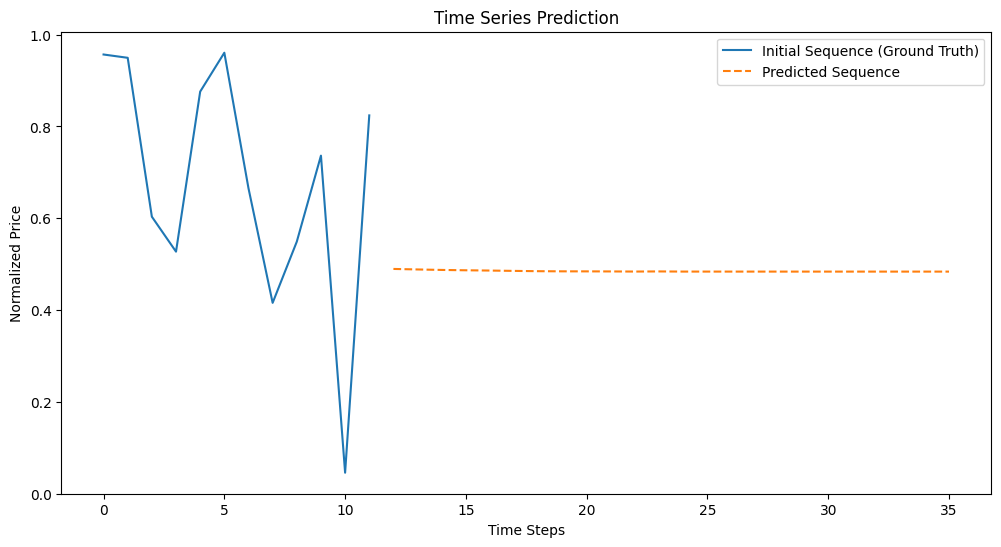

In [ ]:
import matplotlib.pyplot as plt

# Функция для генерации предсказаний временного ряда
def generate_time_series(model, input_sequence, predict_length):
    """
    Генерация временного ряда с использованием обученной модели.

    :param model: Обученная модель RNN
    :param input_sequence: Входная последовательность (numpy array)
    :param predict_length: Длина предсказанного ряда
    :return: Список предсказаний
    """
    model.eval()  # Устанавливаем режим оценки
    input_seq = torch.tensor(input_sequence, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)  # Форматируем вход

    predictions = []
    with torch.no_grad():
        for _ in range(predict_length):
            output = model(input_seq)
            pred_price = output.item()
            predictions.append(pred_price)

            # Добавляем предсказанное значение в последовательность
            new_input = torch.tensor([[pred_price]], dtype=torch.float32).unsqueeze(-1)
            input_seq = torch.cat((input_seq[:, 1:, :], new_input), dim=1)

    return predictions

# Выбираем одну последовательность из тестовых данных
initial_sequence = X_test[0].numpy()  # Берем первую последовательность из тестовых данных
predict_length = 24  # Длина предсказанного временного ряда

# Генерируем предсказания
predicted_series = generate_time_series(model, initial_sequence, predict_length)

# Визуализация реального и предсказанного ряда
plt.figure(figsize=(12, 6))
plt.plot(range(len(initial_sequence)), initial_sequence, label="Initial Sequence (Ground Truth)")
plt.plot(range(len(initial_sequence), len(initial_sequence) + predict_length), predicted_series, label="Predicted Sequence", linestyle='--')
plt.legend()
plt.title("Time Series Prediction")
plt.xlabel("Time Steps")
plt.ylabel("Normalized Price")
plt.show()
